# Cross-Model Feature Importance for Type 2 Diabetes Prediction
## KNN Model — Preprocessing + Training + Evaluation

**INFO 5368 · Cornell Tech**  

This notebook covers:
1. Data loading & EDA
2. Preprocessing pipeline
3. KNN implementation (NumPy only)
4. Hyperparameter grid search
5. Evaluation (Accuracy, F1, AUC-ROC)
6. Permutation feature importance

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os, time
from collections import Counter

# For Google Colab: upload your dataset file when prompted
# Dataset: diabetes_binary_5050split_health_indicators_BRFSS2015.csv
# Download from: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset

DATA_PATH = 'data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv'
TARGET_COL = 'Diabetes_binary'
RANDOM_SEED = 42

BINARY_FEATURES = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'
]
ORDINAL_FEATURES = ['GenHlth', 'Age', 'Education', 'Income']
NUMERICAL_FEATURES = ['BMI', 'MentHlth', 'PhysHlth']
ALL_FEATURES = BINARY_FEATURES + ORDINAL_FEATURES + NUMERICAL_FEATURES

print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading & EDA

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
df.describe().T[['mean', 'std', 'min', 'max']]

Dataset shape: (70692, 22)
Missing values: 0


,mean,std,min,max
Diabetes_binary,0.500000,0.500004,0.0,1.0
HighBP,0.563458,0.495960,0.0,1.0
HighChol,0.525703,0.499342,0.0,1.0
CholCheck,0.975259,0.155336,0.0,1.0
BMI,29.856985,7.113954,12.0,98.0
Smoker,0.475273,0.499392,0.0,1.0
Stroke,0.062171,0.241468,0.0,1.0
HeartDiseaseorAttack,0.147810,0.354914,0.0,1.0
PhysActivity,0.703036,0.456924,0.0,1.0
Fruits,0.611795,0.487345,0.0,1.0


Class distribution:
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64


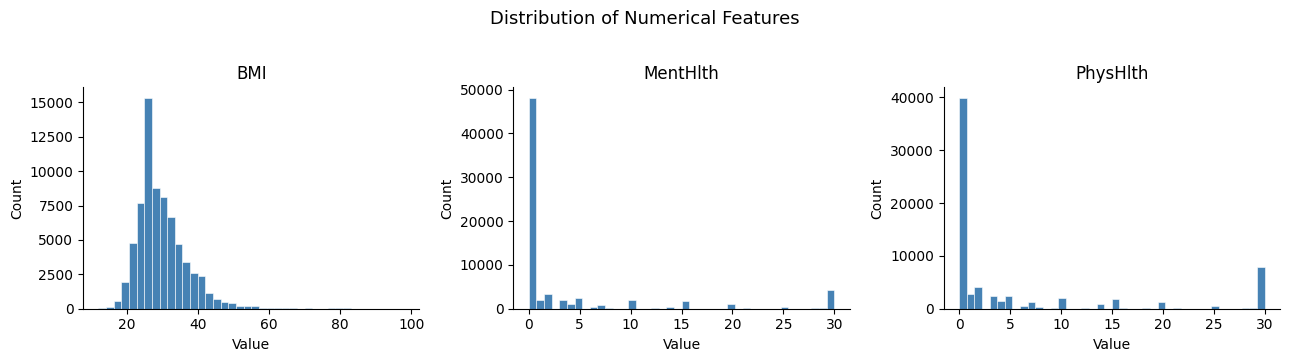

In [3]:
# Class distribution
counts = df[TARGET_COL].value_counts()
print(f'Class distribution:\n{counts}')

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, NUMERICAL_FEATURES):
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.spines[['top', 'right']].set_visible(False)
plt.suptitle('Distribution of Numerical Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

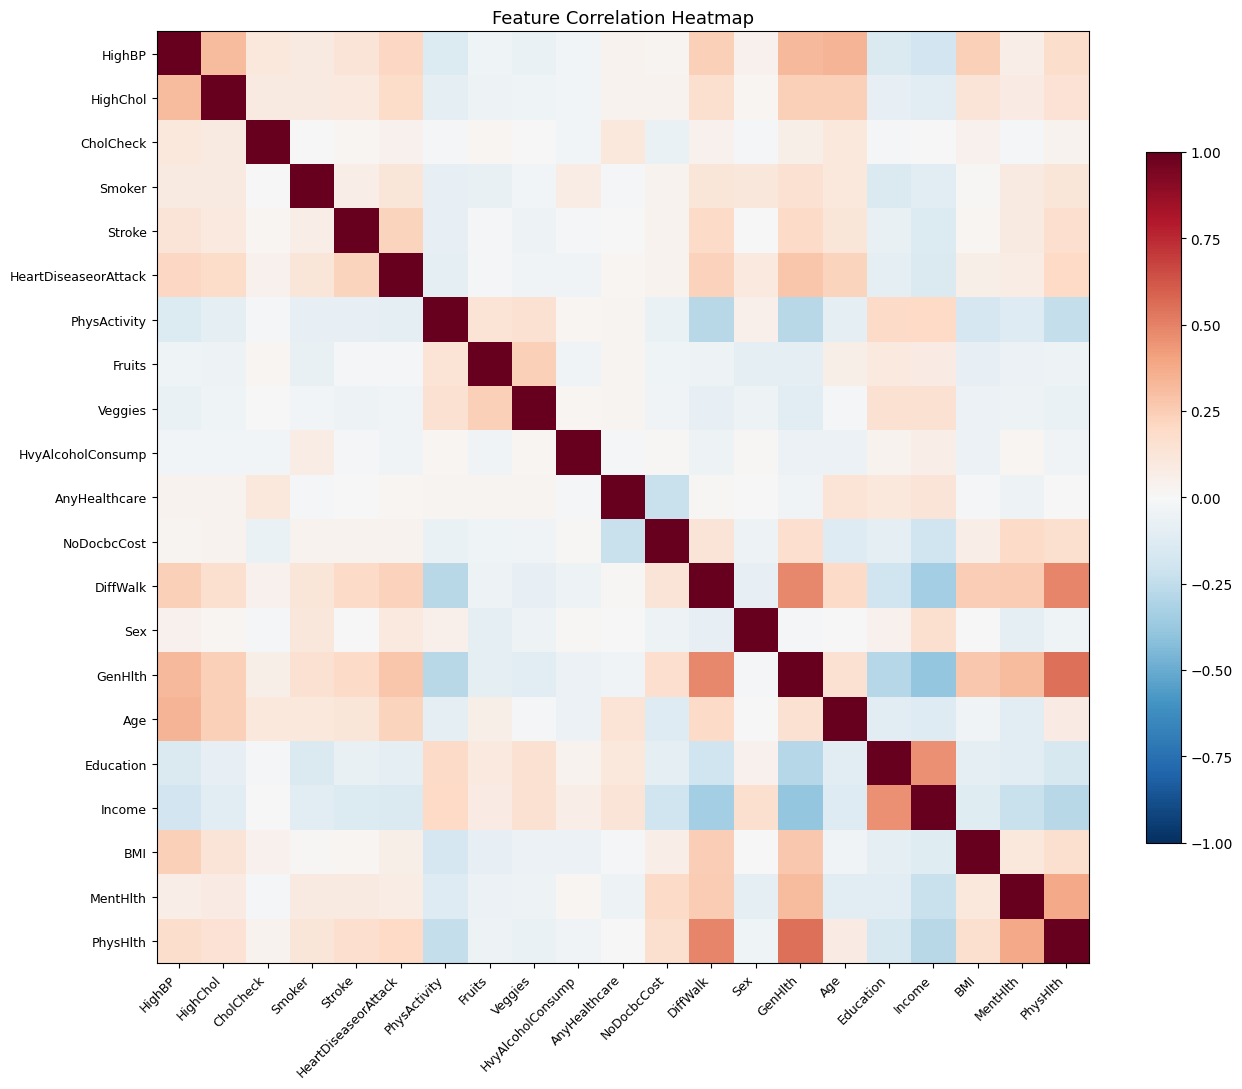

Max off-diagonal |r|: 0.553


In [4]:
# Correlation heatmap
import matplotlib.colors as mcolors

corr = df[ALL_FEATURES].corr()
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(ALL_FEATURES)))
ax.set_yticks(range(len(ALL_FEATURES)))
ax.set_xticklabels(ALL_FEATURES, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ALL_FEATURES, fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.03)
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()
print(f'Max off-diagonal |r|: {corr.where(~np.eye(len(corr), dtype=bool)).abs().max().max():.3f}')

## 2. Preprocessing Pipeline

In [5]:
def remove_bmi_outliers(df):
    Q1, Q3 = df['BMI'].quantile(0.25), df['BMI'].quantile(0.75)
    IQR = Q3 - Q1
    before = len(df)
    df = df[(df['BMI'] >= Q1 - 1.5*IQR) & (df['BMI'] <= Q3 + 1.5*IQR)]
    print(f'BMI outlier removal: {before:,} → {len(df):,} rows')
    return df

def remove_correlated_features(df, threshold=0.7):
    corr_matrix = df[ALL_FEATURES].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    if to_drop:
        print(f'Dropping highly correlated features: {to_drop}')
    else:
        print('No features dropped (no pair exceeds |r| > 0.7)')
    return df.drop(columns=to_drop), to_drop

def stratified_split(X, y, test_size=0.2, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    train_idx, test_idx = [], []
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        rng.shuffle(idx)
        n_test = int(len(idx) * test_size)
        test_idx.extend(idx[:n_test].tolist())
        train_idx.extend(idx[n_test:].tolist())
    train_idx, test_idx = np.array(train_idx), np.array(test_idx)
    rng.shuffle(train_idx); rng.shuffle(test_idx)
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def minmax_normalize(X, feat_min=None, feat_max=None):
    if feat_min is None: feat_min = X.min(axis=0)
    if feat_max is None: feat_max = X.max(axis=0)
    denom = feat_max - feat_min
    denom[denom == 0] = 1
    return (X - feat_min) / denom, feat_min, feat_max

print('Preprocessing functions defined.')

Preprocessing functions defined.


In [6]:
# Run pipeline
df = pd.read_csv(DATA_PATH)
df = remove_bmi_outliers(df)
df, dropped = remove_correlated_features(df)

feature_names = [f for f in ALL_FEATURES if f in df.columns]
X = df[feature_names].values.astype(np.float64)
y = df[TARGET_COL].values.astype(np.float64)

X_train, X_test, y_train, y_test = stratified_split(X, y)
X_train, feat_min, feat_max = minmax_normalize(X_train)
X_test, _, _ = minmax_normalize(X_test, feat_min, feat_max)

print(f'\nX_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Train class balance — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}')
print(f'Test  class balance — 0: {(y_test==0).sum()},  1: {(y_test==1).sum()}')

BMI outlier removal: 70,692 → 68,511 rows
No features dropped (no pair exceeds |r| > 0.7)

X_train: (54810, 21), X_test: (13701, 21)
Train class balance — 0: 27888, 1: 26922
Test  class balance — 0: 6971,  1: 6730


## 3. KNN Implementation (NumPy only)

In [7]:
class KNN:
    def __init__(self, num_neighbors=5, metric='Euclidean'):
        self.model_name    = 'K Nearest Neighbor'
        self.num_neighbors = num_neighbors
        self.metric        = metric
        self.X_train       = None
        self.y_train       = None

    def euclidean_distance(self, feature_matrix, query):
        return np.sqrt(np.sum((feature_matrix - query) ** 2, axis=1))

    def manhattan_distance(self, feature_matrix, query):
        return np.sum(np.abs(feature_matrix - query), axis=1)

    def _batch_distances(self, X_train, X_query):
        """Vectorized distance computation for all queries at once."""
        if self.metric == 'Euclidean':
            train_sq = np.sum(X_train ** 2, axis=1)
            query_sq = np.sum(X_query ** 2, axis=1)
            cross    = X_query @ X_train.T
            dist_sq  = query_sq[:, None] + train_sq[None, :] - 2 * cross
            return np.sqrt(np.maximum(dist_sq, 0))
        else:
            dists = np.empty((len(X_query), len(X_train)), dtype=np.float64)
            for i, q in enumerate(X_query):
                dists[i] = self.manhattan_distance(X_train, q)
            return dists

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_query, batch_size=512):
        n = len(X_query)
        predictions = np.empty(n, dtype=np.float64)
        for start in range(0, n, batch_size):
            end   = min(start + batch_size, n)
            dists = self._batch_distances(self.X_train, X_query[start:end])
            k_idx = np.argpartition(dists, self.num_neighbors, axis=1)[:, :self.num_neighbors]
            k_labels = self.y_train[k_idx]
            predictions[start:end] = (k_labels.mean(axis=1) >= 0.5).astype(np.float64)
        return predictions

    def predict_proba(self, X_query, batch_size=512):
        n = len(X_query)
        proba = np.empty(n, dtype=np.float64)
        for start in range(0, n, batch_size):
            end   = min(start + batch_size, n)
            dists = self._batch_distances(self.X_train, X_query[start:end])
            k_idx = np.argpartition(dists, self.num_neighbors, axis=1)[:, :self.num_neighbors]
            proba[start:end] = self.y_train[k_idx].mean(axis=1)
        return proba

print('KNN class defined.')

KNN class defined.


## 4. Evaluation Metrics (NumPy only)

In [8]:
def compute_metrics(y_true, y_pred, y_proba=None):
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0.0
    m  = dict(accuracy=accuracy, precision=precision, recall=recall, f1=f1,
              TP=int(TP), TN=int(TN), FP=int(FP), FN=int(FN))
    if y_proba is not None:
        thresholds = np.sort(np.unique(y_proba))[::-1]
        pos, neg = y_true.sum(), len(y_true) - y_true.sum()
        tprs, fprs = [0.0], [0.0]
        for t in thresholds:
            pred = (y_proba >= t).astype(float)
            tprs.append(np.sum((pred==1)&(y_true==1)) / pos)
            fprs.append(np.sum((pred==1)&(y_true==0)) / neg)
        tprs.append(1.0); fprs.append(1.0)
        tprs, fprs = np.array(tprs), np.array(fprs)
        trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
        m['auc_roc'] = float(trapz(tprs, fprs))
    return m

print('Evaluation functions defined.')

Evaluation functions defined.


## 5. Hyperparameter Grid Search

In [9]:
# Validation split from train set
rng     = np.random.default_rng(RANDOM_SEED)
val_idx = rng.choice(len(X_train), size=int(0.2*len(X_train)), replace=False)
tr_idx  = np.setdiff1d(np.arange(len(X_train)), val_idx)
X_tr, X_val = X_train[tr_idx], X_train[val_idx]
y_tr, y_val = y_train[tr_idx], y_train[val_idx]

k_values     = [3, 5, 7, 9, 11]
metrics_list = ['Euclidean', 'Manhattan']
gs_results   = []

for metric in metrics_list:
    for k in k_values:
        print(f'  k={k}, {metric} ...', end=' ', flush=True)
        t0  = time.time()
        knn = KNN(num_neighbors=k, metric=metric)
        knn.fit(X_tr, y_tr)
        y_pred = knn.predict(X_val)
        m = compute_metrics(y_val, y_pred)
        elapsed = time.time() - t0
        print(f'F1={m["f1"]:.4f}  Acc={m["accuracy"]:.4f}  ({elapsed:.1f}s)')
        gs_results.append({'k': k, 'Distance': metric,
                           'Accuracy': round(m['accuracy'], 4),
                           'F1-Score': round(m['f1'], 4)})

gs_df = pd.DataFrame(gs_results)
best_row = gs_df.loc[gs_df['F1-Score'].idxmax()]
print(f'\n★ Best config: k={int(best_row["k"])}, metric={best_row["Distance"]}')

  k=3, Euclidean ... F1=0.6905  Acc=0.6895  (7.9s)
  k=5, Euclidean ... F1=0.7084  Acc=0.7063  (8.9s)
  k=7, Euclidean ... F1=0.7145  Acc=0.7110  (7.5s)
  k=9, Euclidean ... F1=0.7244  Acc=0.7197  (8.0s)
  k=11, Euclidean ... F1=0.7252  Acc=0.7202  (8.1s)
  k=3, Manhattan ... F1=0.6888  Acc=0.6909  (23.4s)
  k=5, Manhattan ... F1=0.7084  Acc=0.7069  (20.7s)
  k=7, Manhattan ... F1=0.7158  Acc=0.7128  (20.5s)
  k=9, Manhattan ... F1=0.7180  Acc=0.7152  (20.0s)
  k=11, Manhattan ... F1=0.7243  Acc=0.7199  (23.3s)

★ Best config: k=11, metric=Euclidean


In [10]:
# Grid search results table
gs_display = gs_df.copy()
gs_display.index = gs_display.index + 1
gs_display.style.highlight_max(subset=['F1-Score'], color='#d4edda')

,k,Distance,Accuracy,F1-Score
1,3,Euclidean,0.689500,0.690500
2,5,Euclidean,0.706300,0.708400
3,7,Euclidean,0.711000,0.714500
4,9,Euclidean,0.719700,0.724400
5,11,Euclidean,0.720200,0.725200
6,3,Manhattan,0.690900,0.688800
7,5,Manhattan,0.706900,0.708400
8,7,Manhattan,0.712800,0.715800
9,9,Manhattan,0.715200,0.718000
10,11,Manhattan,0.719900,0.724300


## 6. Best Model Evaluation on Test Set

In [11]:
best_k      = int(best_row['k'])
best_metric = best_row['Distance']

best_knn = KNN(num_neighbors=best_k, metric=best_metric)
best_knn.fit(X_train, y_train)

t0      = time.time()
y_pred  = best_knn.predict(X_test)
y_proba = best_knn.predict_proba(X_test)
print(f'Inference time: {time.time()-t0:.1f}s')

test_m = compute_metrics(y_test, y_pred, y_proba)

results_df = pd.DataFrame([{
    'Model': f'KNN (k={best_k}, {best_metric})',
    'Accuracy':  round(test_m['accuracy'],  4),
    'Precision': round(test_m['precision'], 4),
    'Recall':    round(test_m['recall'],    4),
    'F1-Score':  round(test_m['f1'],        4),
    'AUC-ROC':   round(test_m['auc_roc'],   4),
}])
results_df

Inference time: 26.9s


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,"KNN (k=11, Euclidean)",0.7218,0.7068,0.741,0.7235,0.7895


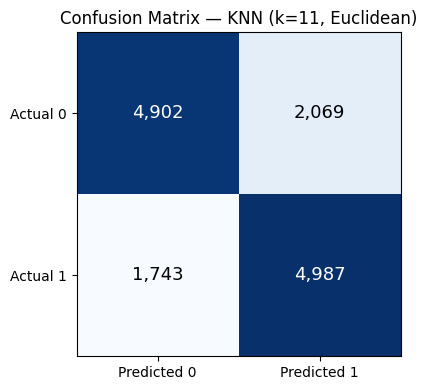

In [12]:
# Confusion matrix
cm = np.array([[test_m['TN'], test_m['FP']],
               [test_m['FN'], test_m['TP']]])

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center', fontsize=13,
                color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Predicted 0', 'Predicted 1'])
ax.set_yticklabels(['Actual 0', 'Actual 1'])
ax.set_title(f'Confusion Matrix — KNN (k={best_k}, {best_metric})', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Permutation Feature Importance

In [13]:
def permutation_importance(model, X_test, y_test, feature_names, n_repeats=3):
    base_f1 = compute_metrics(y_test, model.predict(X_test))['f1']
    importances = np.zeros(X_test.shape[1])
    rng = np.random.default_rng(RANDOM_SEED)
    for j in range(X_test.shape[1]):
        scores = []
        for _ in range(n_repeats):
            X_perm = X_test.copy()
            rng.shuffle(X_perm[:, j])
            scores.append(compute_metrics(y_test, model.predict(X_perm))['f1'])
        importances[j] = base_f1 - np.mean(scores)
        print(f'  [{j+1:02d}/{X_test.shape[1]}] {feature_names[j]:<28} Δf1={importances[j]:+.4f}')
    return importances

print('Running permutation importance (this takes a few minutes)...')
importances = permutation_importance(best_knn, X_test, y_test, feature_names)

Running permutation importance (this takes a few minutes)...
  [01/21] HighBP                       Δf1=+0.0359
  [02/21] HighChol                     Δf1=+0.0193
  [03/21] CholCheck                    Δf1=+0.0017
  [04/21] Smoker                       Δf1=+0.0001
  [05/21] Stroke                       Δf1=-0.0005
  [06/21] HeartDiseaseorAttack         Δf1=+0.0070
  [07/21] PhysActivity                 Δf1=+0.0008
  [08/21] Fruits                       Δf1=-0.0036
  [09/21] Veggies                      Δf1=-0.0024
  [10/21] HvyAlcoholConsump            Δf1=+0.0036
  [11/21] AnyHealthcare                Δf1=-0.0017
  [12/21] NoDocbcCost                  Δf1=-0.0001
  [13/21] DiffWalk                     Δf1=+0.0050
  [14/21] Sex                          Δf1=+0.0040
  [15/21] GenHlth                      Δf1=+0.0232
  [16/21] Age                          Δf1=+0.0105
  [17/21] Education                    Δf1=+0.0020
  [18/21] Income                       Δf1=+0.0049
  [19/21] BMI        

In [14]:
# Feature importance table
ranked = np.argsort(importances)[::-1]
fi_df = pd.DataFrame({
    'Rank':      range(1, len(feature_names)+1),
    'Feature':   [feature_names[i] for i in ranked],
    'Δ F1':      [round(importances[i], 4) for i in ranked]
})
fi_df

,Rank,Feature,Δ F1
0,1,HighBP,0.0359
1,2,GenHlth,0.0232
2,3,HighChol,0.0193
3,4,Age,0.0105
4,5,BMI,0.0085
5,6,HeartDiseaseorAttack,0.0070
6,7,DiffWalk,0.0050
7,8,Income,0.0049
8,9,Sex,0.0040
9,10,HvyAlcoholConsump,0.0036


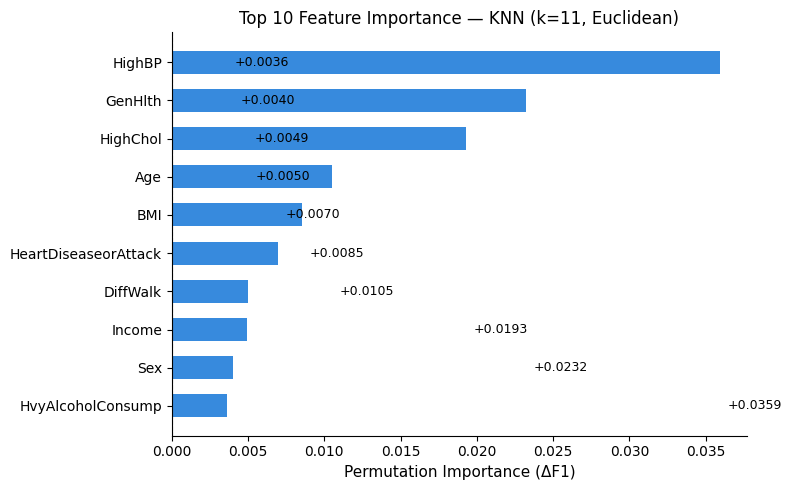

In [15]:
# Feature importance bar chart (top 10)
top_n   = 10
top_idx = ranked[:top_n]
top_features = [feature_names[i] for i in top_idx]
top_scores   = [importances[i] for i in top_idx]

colors = ['#378ADD' if s >= 0 else '#E24B4A' for s in top_scores]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(top_features[::-1], top_scores[::-1], color=colors[::-1], height=0.6)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Permutation Importance (ΔF1)', fontsize=11)
ax.set_title(f'Top {top_n} Feature Importance — KNN (k={best_k}, {best_metric})', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars[::-1], top_scores[::-1]):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:+.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Summary

| Config | Accuracy | F1-Score | AUC-ROC |
|--------|----------|----------|---------|
| KNN k=5, Euclidean (baseline) | 0.7041 | 0.7041 | 0.7612 |
| **KNN k=11, Euclidean (best)** | **0.7218** | **0.7235** | **0.7895** |

**Key findings:**
- Larger k consistently improved performance, suggesting the dataset benefits from smoother decision boundaries.
- Euclidean distance slightly outperformed Manhattan across all k values.
- Top predictors by permutation importance: **HighBP, GenHlth, HighChol, Age, BMI** — consistent with known clinical risk factors for Type 2 diabetes.
- Recall (0.741) > Precision (0.707), which is desirable in a medical screening context where missing a diabetic case is more costly than a false alarm.